# Beyond Linear PCA: Kernel PCA, t-SNE, and UMAP

Companion notebook for the blog post [*Beyond Linear PCA: Kernel PCA, t-SNE, and UMAP*](../blog_posts/blog_kernel_tsne_umap_2026-03-27.md).

This notebook follows the same Breast Cancer Wisconsin dataset used in the [PCA walkthrough](./PCA_Example.ipynb) and applies three non-linear dimensionality reduction methods:

1. **Kernel PCA** — PCA in an implicit high-dimensional feature space via the kernel trick
2. **t-SNE** — Preserve local neighborhood structure for 2D/3D visualization
3. **UMAP** — Fast, topology-preserving embedding that supports out-of-sample projection

**Requirements:** `pip install umap-learn`

## 1. Setup

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import TSNE

import umap

import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Plot style
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

# Colour palette — malignant=coral, benign=steelblue
COLORS = {0: '#E07B72', 1: '#4C8FAF'}   # 0=malignant, 1=benign
LABELS = {0: 'Malignant', 1: 'Benign'}

In [2]:
# ── Load & standardize ────────────────────────────────────────────────────────
bc = load_breast_cancer()
X_raw = bc.data          # (569, 30)
y     = bc.target        # 0=malignant, 1=benign

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f"Dataset: {X_raw.shape[0]} samples, {X_raw.shape[1]} features")
print(f"Malignant: {(y==0).sum()}  |  Benign: {(y==1).sum()}")

# Point colours for every plot
c_vec = [COLORS[label] for label in y]

Dataset: 569 samples, 30 features
Malignant: 212  |  Benign: 357


---
## 2. Kernel PCA — RBF Kernel

Kernel PCA runs PCA in the implicit feature space defined by the kernel function $k(x_i, x_j)$. For the RBF kernel:

$$k_{\text{RBF}}(x_i, x_j) = \exp\!\left(-\gamma \|x_i - x_j\|^2\right)$$

The hyperparameter $\gamma$ controls how quickly similarity falls off with distance.

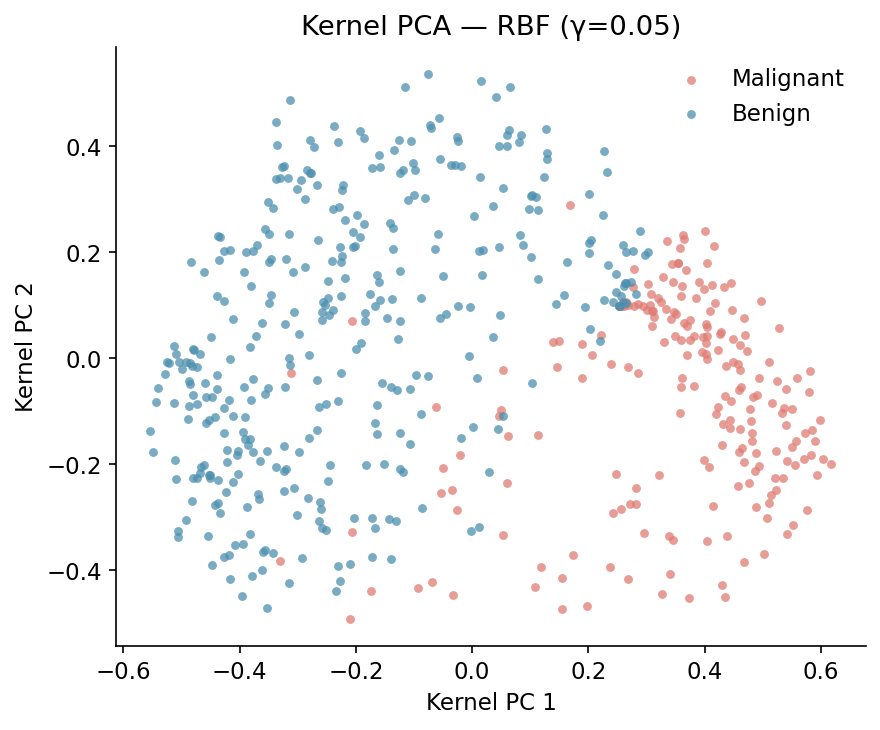

Saved plots/kpca_rbf_scatter.png


In [3]:
# ── RBF Kernel PCA ─────────────────────────────────────────────────────────────
kpca_rbf = KernelPCA(n_components=2, kernel='rbf', gamma=0.05, random_state=SEED)
Z_kpca_rbf = kpca_rbf.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(6, 5))
for label in [0, 1]:
    mask = y == label
    ax.scatter(Z_kpca_rbf[mask, 0], Z_kpca_rbf[mask, 1],
               c=COLORS[label], label=LABELS[label],
               s=18, alpha=0.75, linewidths=0)

ax.set_xlabel('Kernel PC 1')
ax.set_ylabel('Kernel PC 2')
ax.set_title('Kernel PCA — RBF (γ=0.05)')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig('plots/kpca_rbf_scatter.png', dpi=150)
plt.show()
print("Saved plots/kpca_rbf_scatter.png")

### Effect of γ on RBF Kernel PCA

Small γ → wide Gaussian, samples are broadly similar → PCA-like embedding.  
Large γ → narrow Gaussian, only nearest neighbours count → tight local clusters.

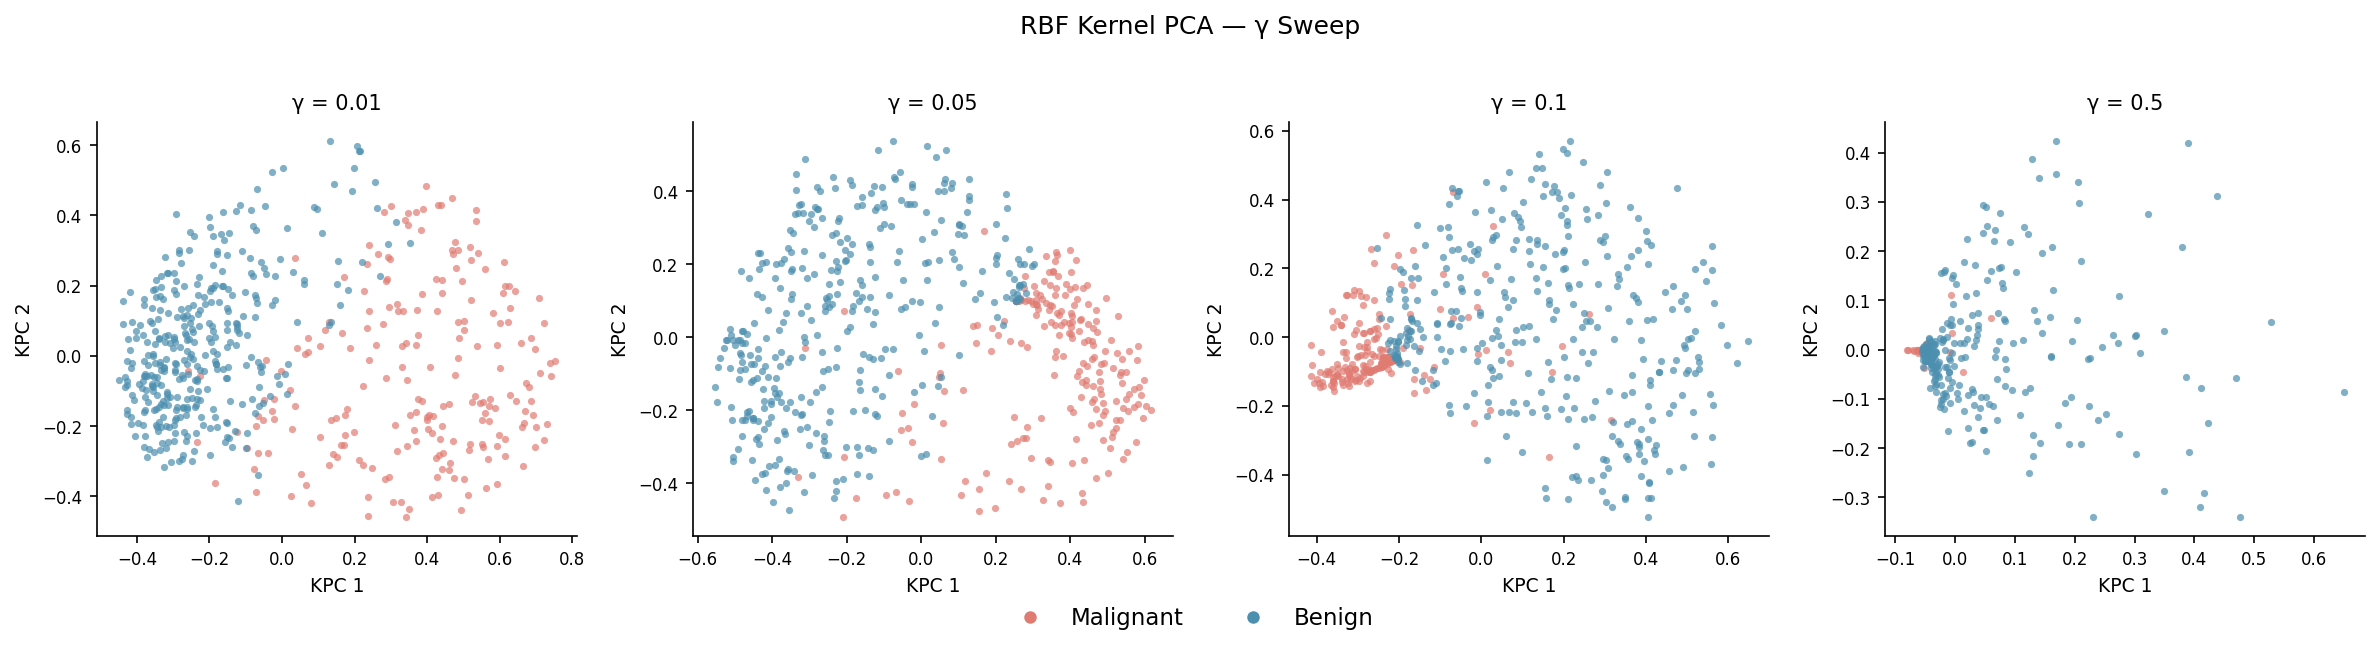

Saved plots/kpca_rbf_gamma_sweep.png


In [4]:
# ── γ sensitivity sweep ────────────────────────────────────────────────────────
gammas = [0.01, 0.05, 0.1, 0.5]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, g in zip(axes, gammas):
    Z = KernelPCA(n_components=2, kernel='rbf', gamma=g, random_state=SEED).fit_transform(X_scaled)
    for label in [0, 1]:
        mask = y == label
        ax.scatter(Z[mask, 0], Z[mask, 1],
                   c=COLORS[label], label=LABELS[label],
                   s=12, alpha=0.7, linewidths=0)
    ax.set_title(f'γ = {g}', fontsize=10)
    ax.set_xlabel('KPC 1', fontsize=9)
    ax.set_ylabel('KPC 2', fontsize=9)
    ax.tick_params(labelsize=8)

handles = [Line2D([0],[0], marker='o', color='w', markerfacecolor=COLORS[l],
                  markersize=7, label=LABELS[l]) for l in [0, 1]]
fig.legend(handles=handles, loc='lower center', ncol=2, frameon=False,
           bbox_to_anchor=(0.5, -0.05))
plt.suptitle('RBF Kernel PCA — γ Sweep', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('plots/kpca_rbf_gamma_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved plots/kpca_rbf_gamma_sweep.png")

---
## 3. Kernel PCA — Polynomial Kernel

$$k_{\text{poly}}(x_i, x_j) = (\gamma\, x_i \cdot x_j + r)^d$$

where $d$ is the polynomial degree and $r$ (`coef0`) is a free additive constant.

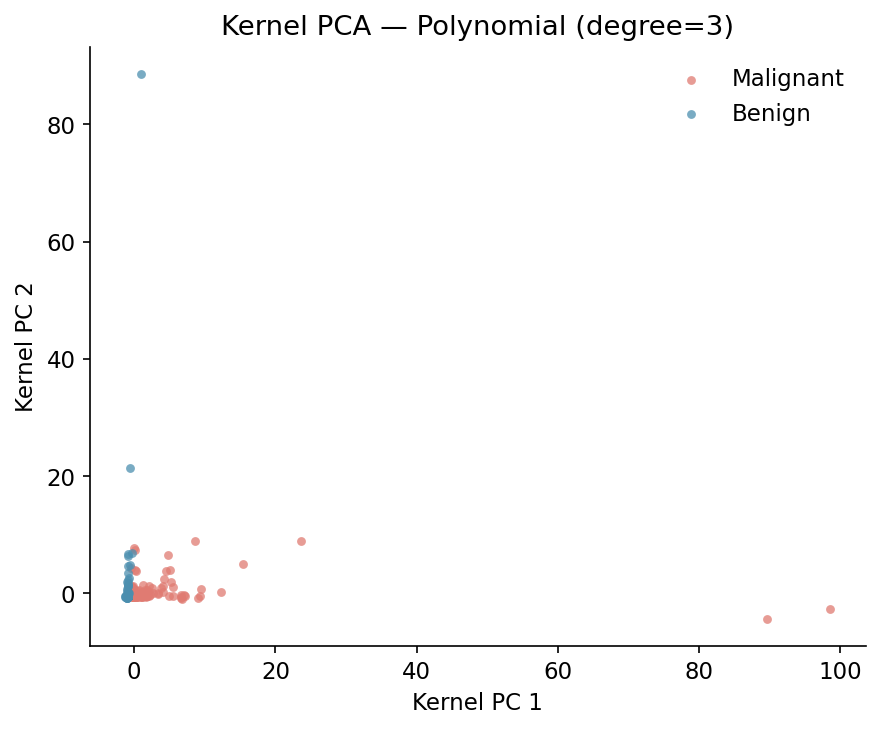

Saved plots/kpca_poly_scatter.png


In [5]:
# ── Polynomial Kernel PCA ──────────────────────────────────────────────────────
kpca_poly = KernelPCA(n_components=2, kernel='poly', degree=3,
                      gamma=0.05, coef0=1, random_state=SEED)
Z_kpca_poly = kpca_poly.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(6, 5))
for label in [0, 1]:
    mask = y == label
    ax.scatter(Z_kpca_poly[mask, 0], Z_kpca_poly[mask, 1],
               c=COLORS[label], label=LABELS[label],
               s=18, alpha=0.75, linewidths=0)
ax.set_xlabel('Kernel PC 1')
ax.set_ylabel('Kernel PC 2')
ax.set_title('Kernel PCA — Polynomial (degree=3)')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig('plots/kpca_poly_scatter.png', dpi=150)
plt.show()
print("Saved plots/kpca_poly_scatter.png")

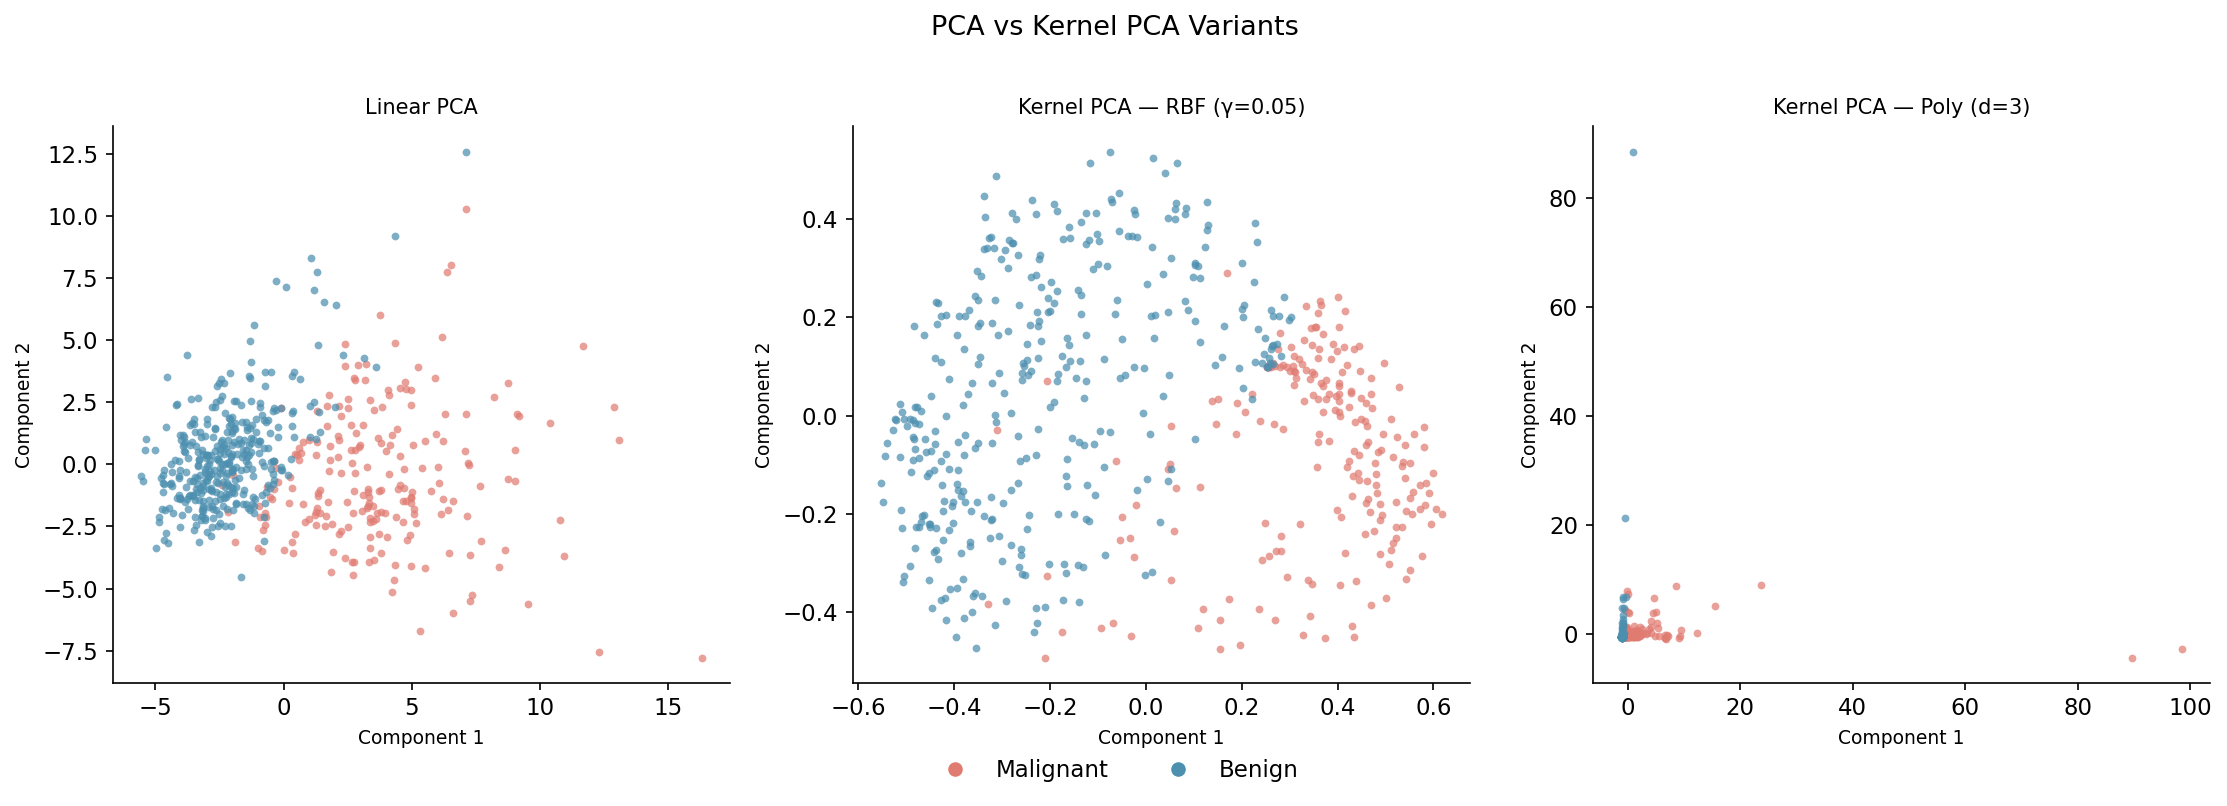

Saved plots/kpca_comparison.png


In [6]:
# ── Side-by-side kernel comparison ────────────────────────────────────────────
# Linear PCA for reference
Z_pca = PCA(n_components=2, random_state=SEED).fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
datasets = [
    (Z_pca,       'Linear PCA'),
    (Z_kpca_rbf,  'Kernel PCA — RBF (γ=0.05)'),
    (Z_kpca_poly, 'Kernel PCA — Poly (d=3)'),
]
for ax, (Z, title) in zip(axes, datasets):
    for label in [0, 1]:
        mask = y == label
        ax.scatter(Z[mask, 0], Z[mask, 1],
                   c=COLORS[label], label=LABELS[label],
                   s=14, alpha=0.72, linewidths=0)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Component 1', fontsize=9)
    ax.set_ylabel('Component 2', fontsize=9)

handles = [Line2D([0],[0], marker='o', color='w', markerfacecolor=COLORS[l],
                  markersize=8, label=LABELS[l]) for l in [0, 1]]
fig.legend(handles=handles, loc='lower center', ncol=2, frameon=False,
           bbox_to_anchor=(0.5, -0.04))
plt.suptitle('PCA vs Kernel PCA Variants', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('plots/kpca_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved plots/kpca_comparison.png")

---
## 4. t-SNE — Perplexity Sweep

t-SNE's `perplexity` is roughly the effective number of neighbours each point considers. Low perplexity → fine local structure; high perplexity → broader, more global view. Always sweep before committing to a value.

In [7]:
# ── t-SNE perplexity sweep ─────────────────────────────────────────────────────
perplexities = [5, 15, 30, 50]
tsne_results = {}

for perp in perplexities:
    t0 = time.time()
    Z = TSNE(n_components=2, perplexity=perp, max_iter=1000,
             learning_rate='auto', init='pca',
             random_state=SEED).fit_transform(X_scaled)
    elapsed = time.time() - t0
    tsne_results[perp] = Z
    print(f"perplexity={perp:>3}  time={elapsed:.1f}s")

perplexity=  5  time=2.8s


perplexity= 15  time=0.8s


perplexity= 30  time=0.9s


perplexity= 50  time=1.2s


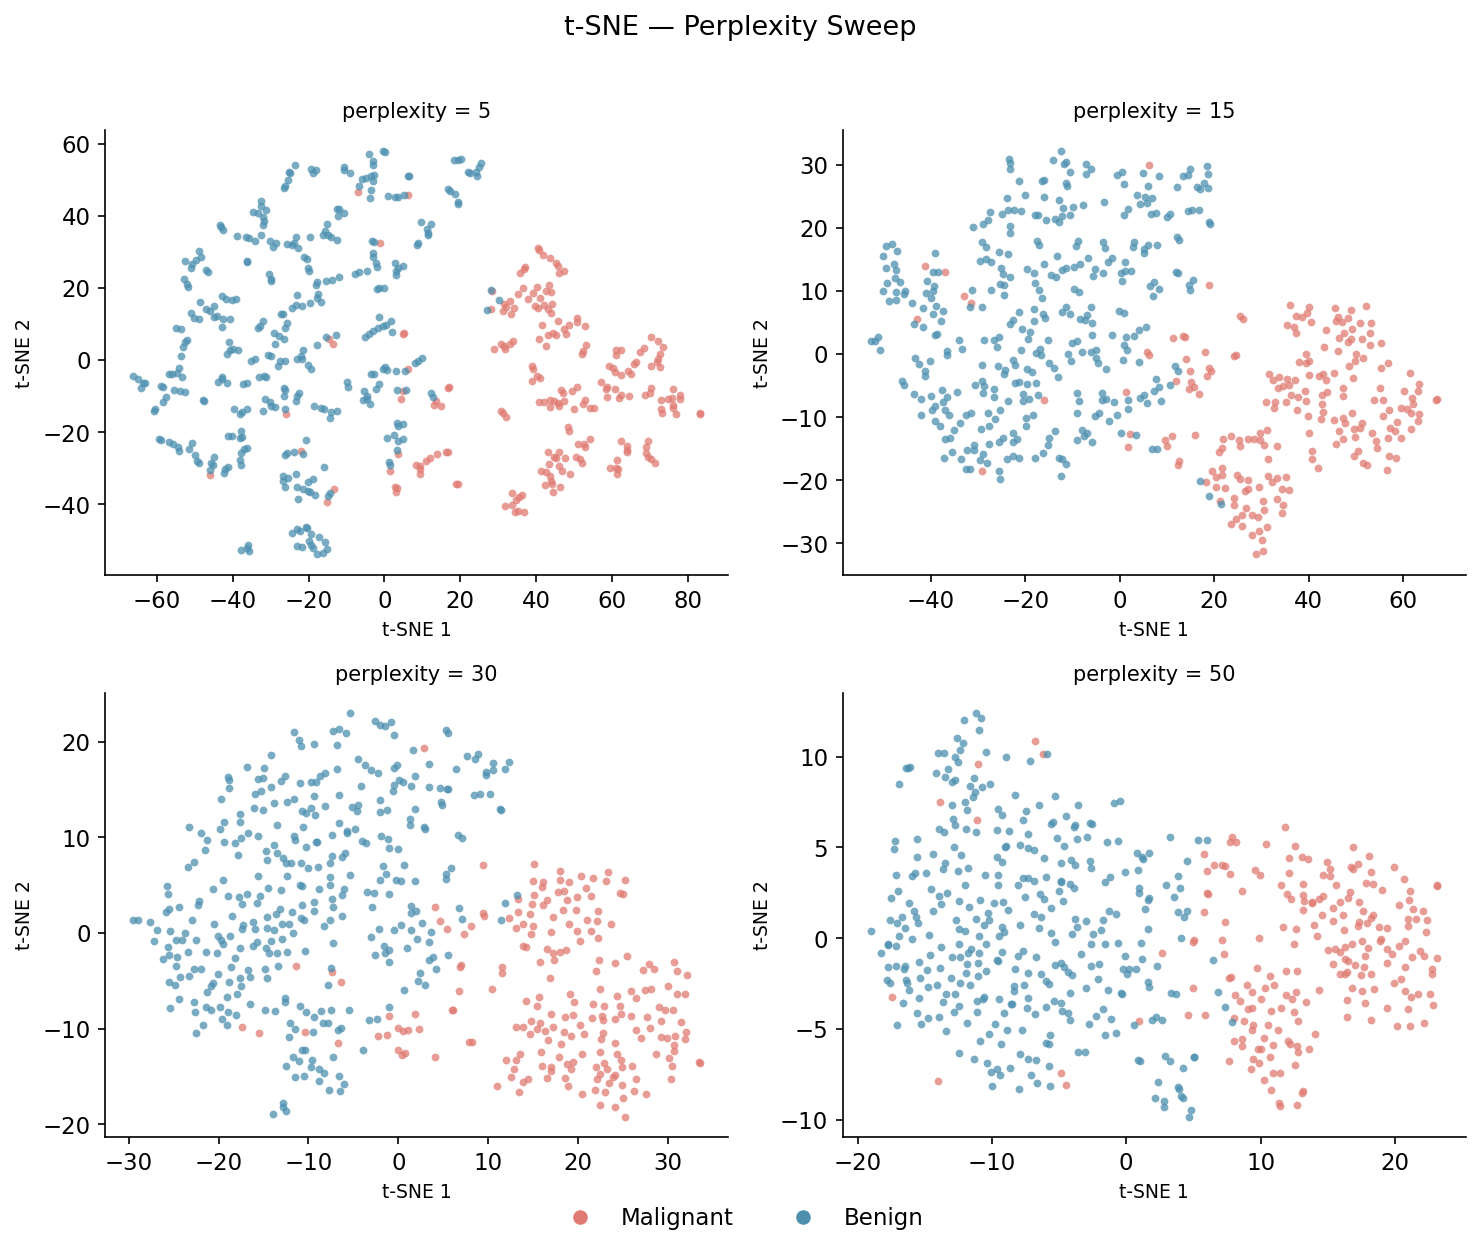

Saved plots/tsne_perplexity_grid.png


In [8]:
# ── Plot perplexity grid ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, perp in zip(axes, perplexities):
    Z = tsne_results[perp]
    for label in [0, 1]:
        mask = y == label
        ax.scatter(Z[mask, 0], Z[mask, 1],
                   c=COLORS[label], label=LABELS[label],
                   s=14, alpha=0.75, linewidths=0)
    ax.set_title(f'perplexity = {perp}', fontsize=10)
    ax.set_xlabel('t-SNE 1', fontsize=9)
    ax.set_ylabel('t-SNE 2', fontsize=9)

handles = [Line2D([0],[0], marker='o', color='w', markerfacecolor=COLORS[l],
                  markersize=8, label=LABELS[l]) for l in [0, 1]]
fig.legend(handles=handles, loc='lower center', ncol=2, frameon=False,
           bbox_to_anchor=(0.5, -0.02))
plt.suptitle('t-SNE — Perplexity Sweep', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('plots/tsne_perplexity_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved plots/tsne_perplexity_grid.png")

---
## 5. t-SNE — Final Result (perplexity = 30)

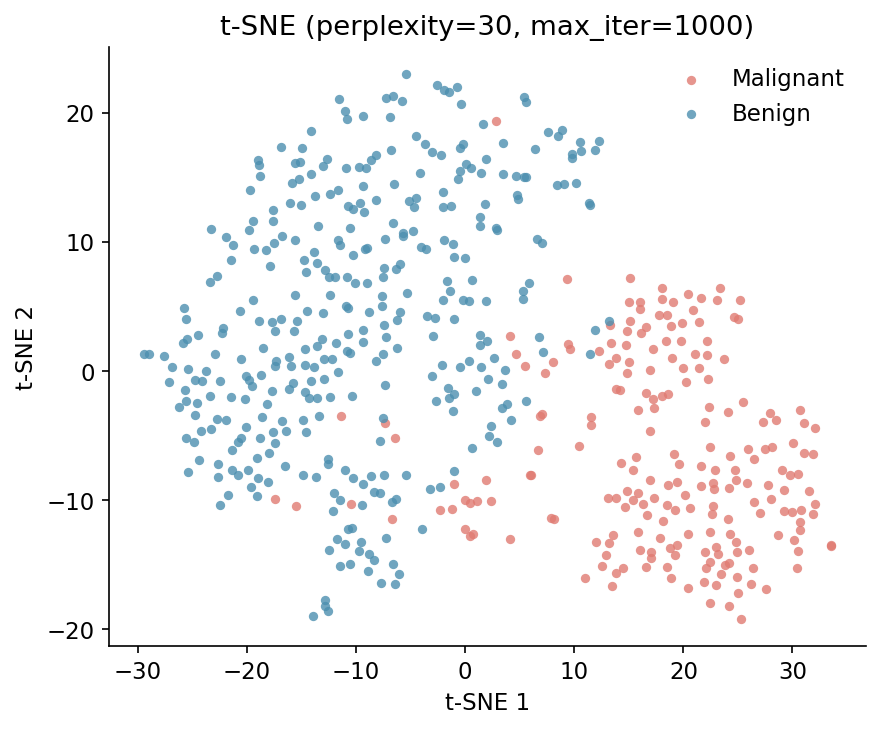

Saved plots/tsne_scatter.png


In [9]:
# ── Final t-SNE embedding ──────────────────────────────────────────────────────
Z_tsne = tsne_results[30]   # already computed above

fig, ax = plt.subplots(figsize=(6, 5))
for label in [0, 1]:
    mask = y == label
    ax.scatter(Z_tsne[mask, 0], Z_tsne[mask, 1],
               c=COLORS[label], label=LABELS[label],
               s=20, alpha=0.8, linewidths=0)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_title('t-SNE (perplexity=30, max_iter=1000)')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig('plots/tsne_scatter.png', dpi=150)
plt.show()
print("Saved plots/tsne_scatter.png")

---
## 6. UMAP — n_neighbors Sweep

`n_neighbors` balances local vs global structure. Small values (5–10) capture fine local topology; large values (30–50) emphasise global structure at the cost of local detail.

In [10]:
# ── UMAP n_neighbors sweep ─────────────────────────────────────────────────────
neighbor_vals = [5, 15, 30, 50]
umap_results = {}

for nn in neighbor_vals:
    t0 = time.time()
    Z = umap.UMAP(n_components=2, n_neighbors=nn, min_dist=0.1,
                  random_state=SEED).fit_transform(X_scaled)
    elapsed = time.time() - t0
    umap_results[nn] = Z
    print(f"n_neighbors={nn:>3}  time={elapsed:.1f}s")

n_neighbors=  5  time=7.4s


n_neighbors= 15  time=0.8s


n_neighbors= 30  time=0.9s


n_neighbors= 50  time=1.1s


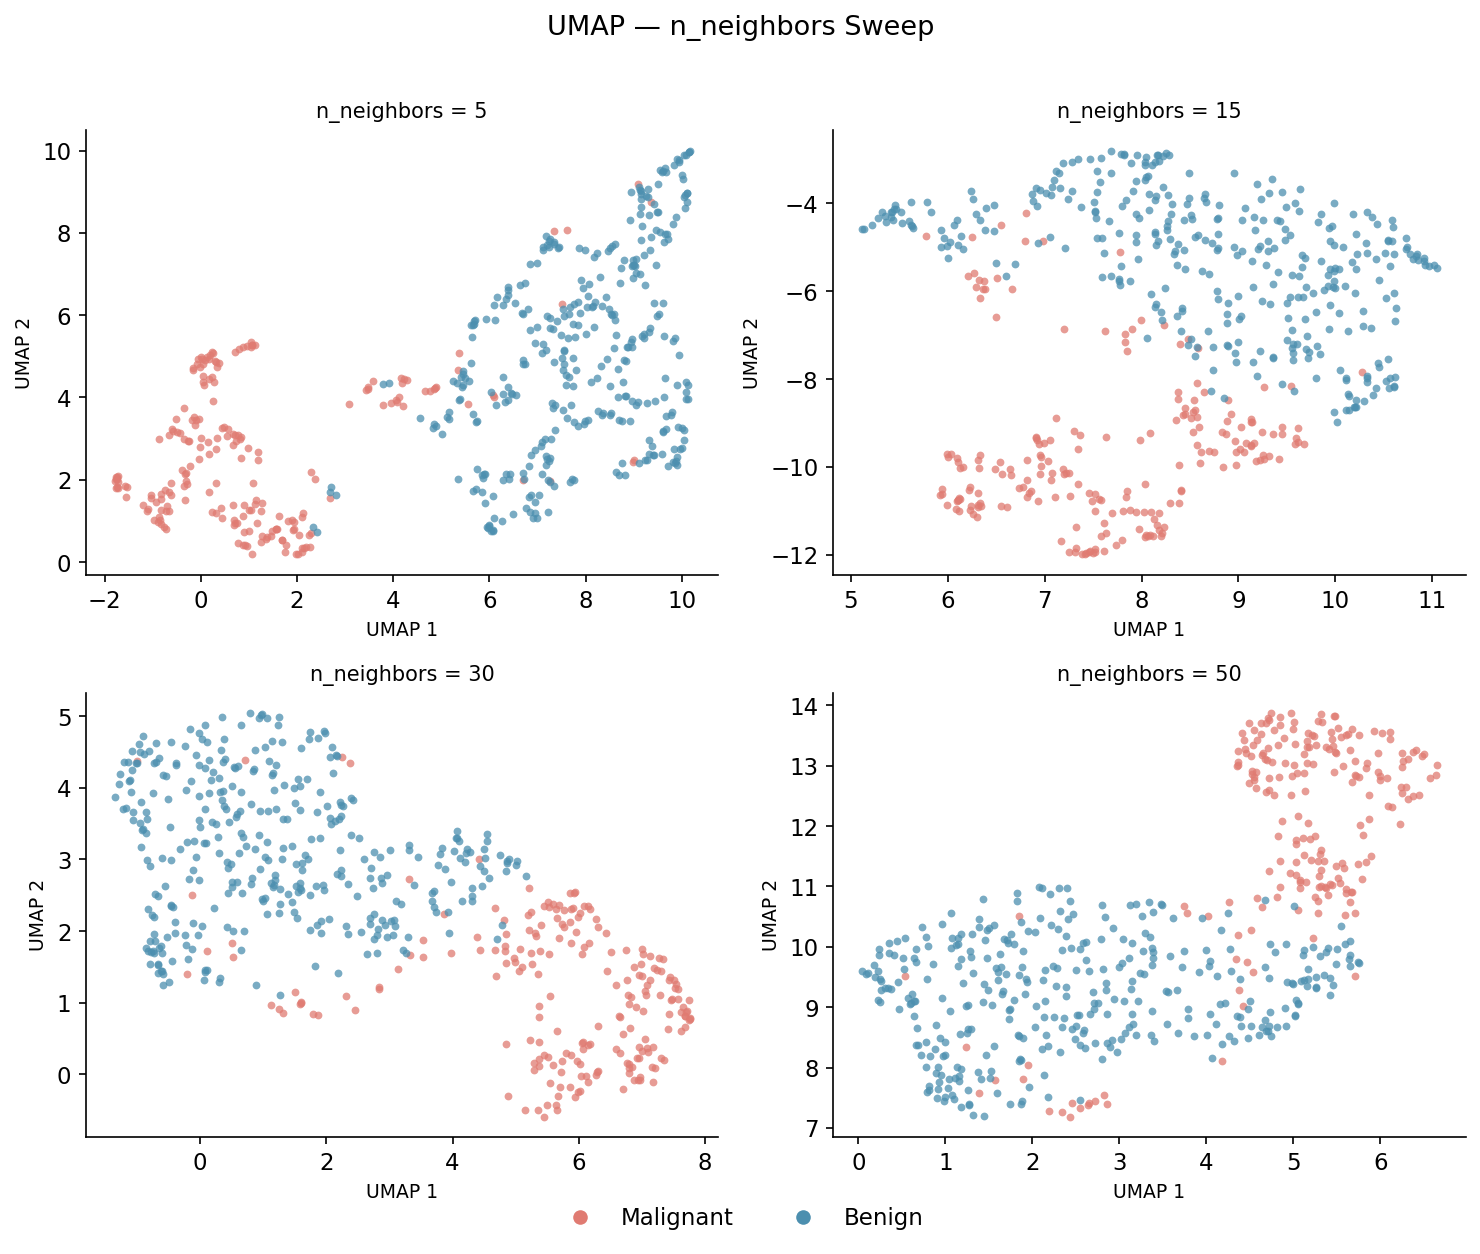

Saved plots/umap_neighbors_grid.png


In [11]:
# ── Plot n_neighbors grid ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, nn in zip(axes, neighbor_vals):
    Z = umap_results[nn]
    for label in [0, 1]:
        mask = y == label
        ax.scatter(Z[mask, 0], Z[mask, 1],
                   c=COLORS[label], label=LABELS[label],
                   s=14, alpha=0.75, linewidths=0)
    ax.set_title(f'n_neighbors = {nn}', fontsize=10)
    ax.set_xlabel('UMAP 1', fontsize=9)
    ax.set_ylabel('UMAP 2', fontsize=9)

handles = [Line2D([0],[0], marker='o', color='w', markerfacecolor=COLORS[l],
                  markersize=8, label=LABELS[l]) for l in [0, 1]]
fig.legend(handles=handles, loc='lower center', ncol=2, frameon=False,
           bbox_to_anchor=(0.5, -0.02))
plt.suptitle('UMAP — n_neighbors Sweep', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('plots/umap_neighbors_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved plots/umap_neighbors_grid.png")

---
## 7. UMAP — Final Result (n_neighbors = 15)

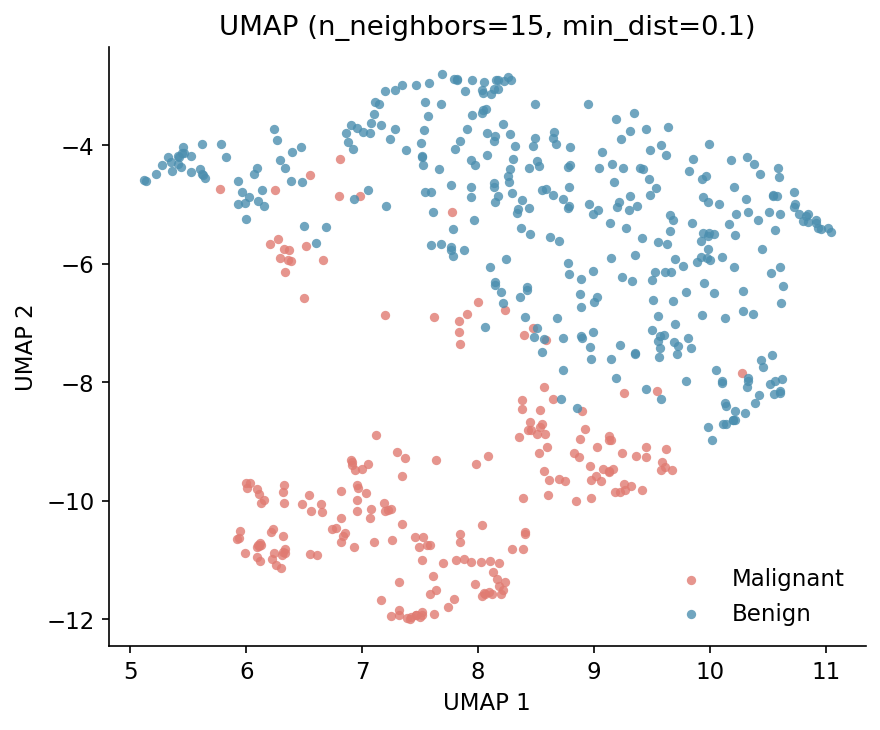

Saved plots/umap_scatter.png


In [12]:
# ── Final UMAP embedding ───────────────────────────────────────────────────────
Z_umap = umap_results[15]   # already computed above

fig, ax = plt.subplots(figsize=(6, 5))
for label in [0, 1]:
    mask = y == label
    ax.scatter(Z_umap[mask, 0], Z_umap[mask, 1],
               c=COLORS[label], label=LABELS[label],
               s=20, alpha=0.8, linewidths=0)
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('UMAP (n_neighbors=15, min_dist=0.1)')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig('plots/umap_scatter.png', dpi=150)
plt.show()
print("Saved plots/umap_scatter.png")

---
## 8. Four-Way Method Comparison

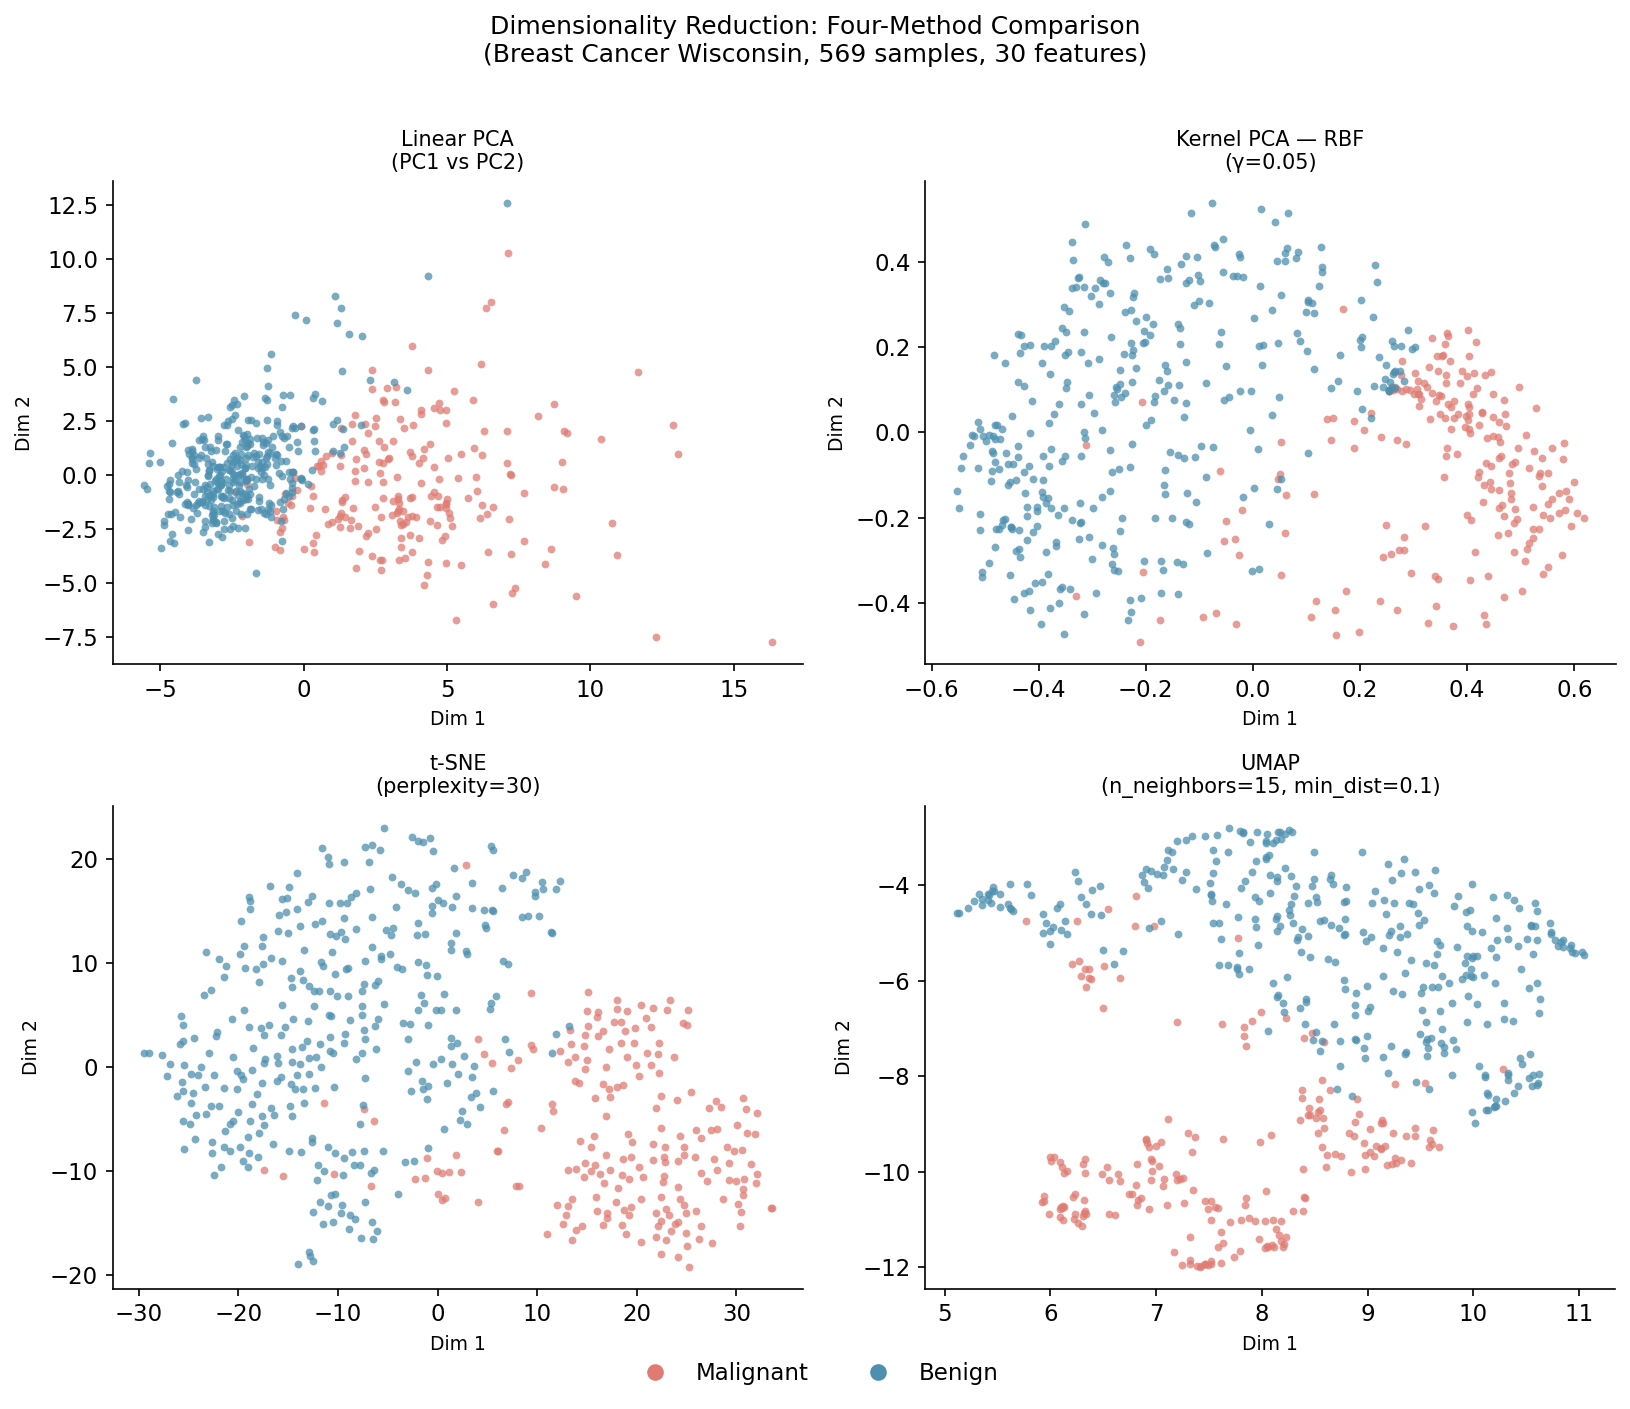

Saved plots/method_comparison.png


In [13]:
# ── 2×2 comparison grid ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

panels = [
    (Z_pca,       'Linear PCA\n(PC1 vs PC2)'),
    (Z_kpca_rbf,  'Kernel PCA — RBF\n(γ=0.05)'),
    (Z_tsne,      't-SNE\n(perplexity=30)'),
    (Z_umap,      'UMAP\n(n_neighbors=15, min_dist=0.1)'),
]
for ax, (Z, title) in zip(axes, panels):
    for label in [0, 1]:
        mask = y == label
        ax.scatter(Z[mask, 0], Z[mask, 1],
                   c=COLORS[label], label=LABELS[label],
                   s=14, alpha=0.75, linewidths=0)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Dim 1', fontsize=9)
    ax.set_ylabel('Dim 2', fontsize=9)

handles = [Line2D([0],[0], marker='o', color='w', markerfacecolor=COLORS[l],
                  markersize=9, label=LABELS[l]) for l in [0, 1]]
fig.legend(handles=handles, loc='lower center', ncol=2, frameon=False,
           bbox_to_anchor=(0.5, -0.02), fontsize=11)
plt.suptitle('Dimensionality Reduction: Four-Method Comparison\n(Breast Cancer Wisconsin, 569 samples, 30 features)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('plots/method_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved plots/method_comparison.png")

---
## 9. Timing Comparison

Linear PCA             0.00s
Kernel PCA (RBF)       0.01s


t-SNE                  0.93s


UMAP                   0.79s


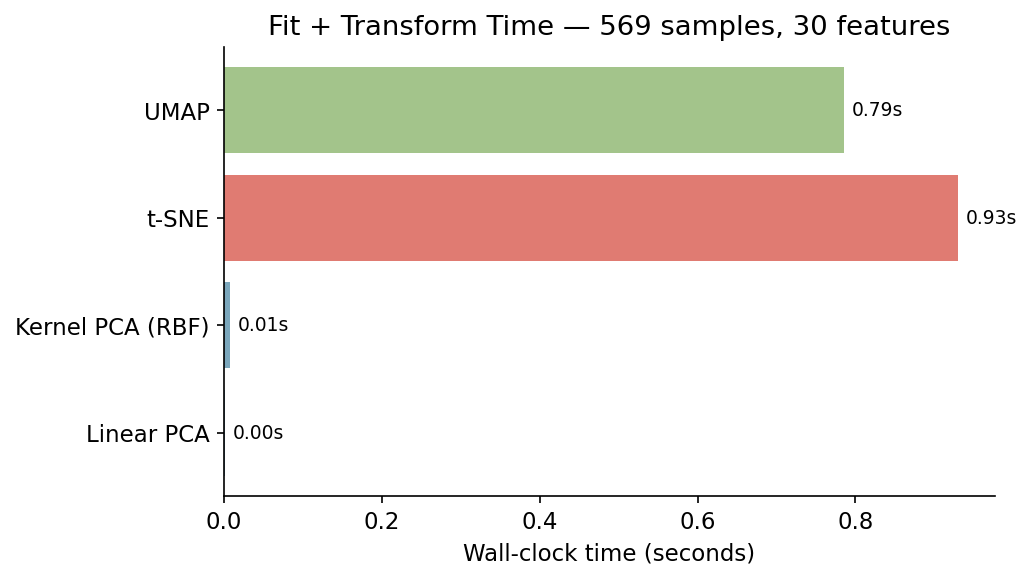

Saved plots/timing_comparison.png


In [14]:
# ── Wall-clock timing for all four methods ─────────────────────────────────────
timing = {}

methods = {
    'Linear PCA': lambda: PCA(n_components=2, random_state=SEED).fit_transform(X_scaled),
    'Kernel PCA (RBF)': lambda: KernelPCA(n_components=2, kernel='rbf',
                                           gamma=0.05, random_state=SEED).fit_transform(X_scaled),
    't-SNE': lambda: TSNE(n_components=2, perplexity=30, max_iter=1000,
                          learning_rate='auto', init='pca',
                          random_state=SEED).fit_transform(X_scaled),
    'UMAP': lambda: umap.UMAP(n_components=2, n_neighbors=15,
                               min_dist=0.1, random_state=SEED).fit_transform(X_scaled),
}

for name, fn in methods.items():
    t0 = time.time()
    fn()
    elapsed = time.time() - t0
    timing[name] = elapsed
    print(f"{name:<22} {elapsed:.2f}s")

# ── Bar chart ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(list(timing.keys()), list(timing.values()),
               color=['#7BA7BC', '#7BA7BC', '#E07B72', '#A3C48B'])
ax.set_xlabel('Wall-clock time (seconds)')
ax.set_title('Fit + Transform Time — 569 samples, 30 features')
for bar, val in zip(bars, timing.values()):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}s', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('plots/timing_comparison.png', dpi=150)
plt.show()
print("Saved plots/timing_comparison.png")